Dataset Preview:
   Customer_ID Agent Issue_Type  Response_Time_Min  Resolution_Time_Min  \
0            1  John      Login                 33                  121   
1            2  Neha      Login                 51                   69   
2            3  Amit     Refund                 42                   11   
3            4  John      Login                 44                  263   
4            5  John      Login                 24                  149   

   Rating  
0       5  
1       4  
2       1  
3       4  
4       3  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Customer_ID          100 non-null    int64 
 1   Agent                100 non-null    object
 2   Issue_Type           100 non-null    object
 3   Response_Time_Min    100 non-null    int64 
 4   Resolution_Time_Min  100 non-null    int64 

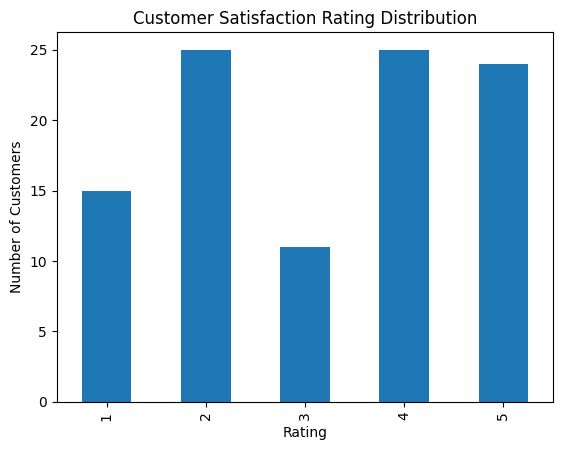

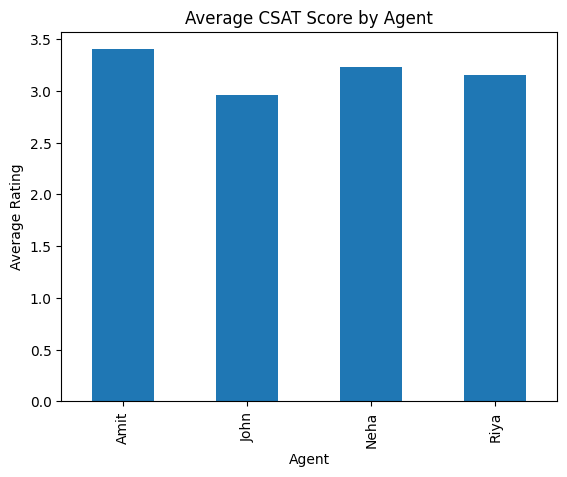

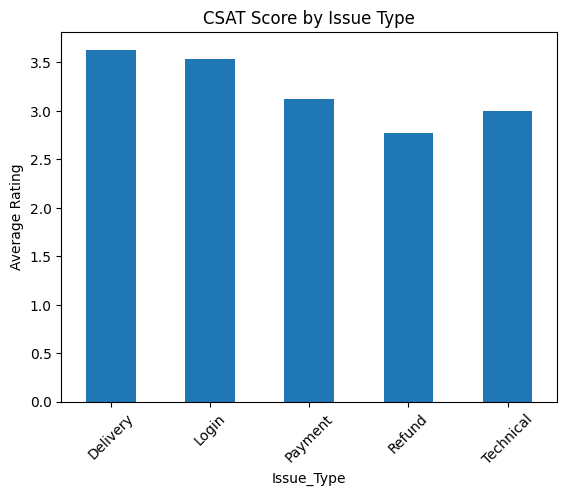

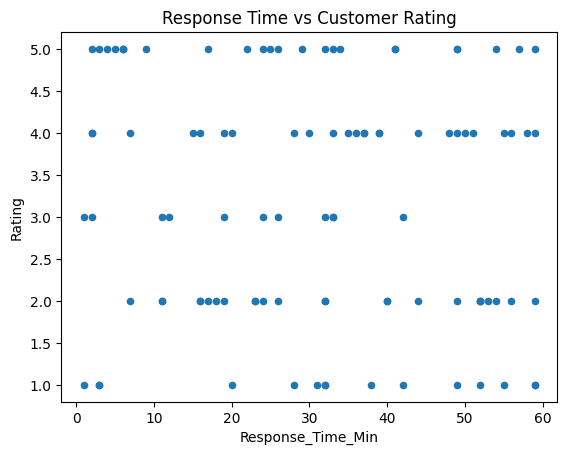


High Satisfaction Customers: 49.00%
Low Satisfaction Customers: 40.00%

================ BUSINESS INSIGHTS ================

1. Faster response times generally lead to higher ratings.
2. Agents with lower CSAT scores may need training.
3. Certain issue types reduce satisfaction more than others.
4. Reducing resolution time can improve customer experience.

Recommended Actions:
- Prioritize high-resolution delays.
- Improve handling of low-rated issue categories.
- Monitor agent performance weekly.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

data = {
    "Customer_ID": range(1,101),
    "Agent": np.random.choice(["Amit","Riya","John","Neha"], 100),
    "Issue_Type": np.random.choice(
        ["Payment","Login","Delivery","Refund","Technical"], 100),
    "Response_Time_Min": np.random.randint(1,60,100),
    "Resolution_Time_Min": np.random.randint(10,300,100),
    "Rating": np.random.randint(1,6,100)
}

df = pd.DataFrame(data)

print("Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

avg_csat = df["Rating"].mean()
print(f"\nOverall CSAT Score: {avg_csat:.2f} / 5")

csat_distribution = df["Rating"].value_counts().sort_index()
print("\nCSAT Distribution:")
print(csat_distribution)

agent_csat = df.groupby("Agent")["Rating"].mean()
print("\nAverage Rating by Agent:")
print(agent_csat)

issue_csat = df.groupby("Issue_Type")["Rating"].mean()
print("\nAverage Rating by Issue Type:")
print(issue_csat)

operation_analysis = df.groupby("Rating")[[
    "Response_Time_Min",
    "Resolution_Time_Min"
]].mean()

print("\nOperational Metrics vs Ratings:")
print(operation_analysis)

csat_distribution.plot(kind="bar")
plt.title("Customer Satisfaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.show()

agent_csat.plot(kind="bar")
plt.title("Average CSAT Score by Agent")
plt.ylabel("Average Rating")
plt.show()

issue_csat.plot(kind="bar")
plt.title("CSAT Score by Issue Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

df.plot.scatter(x="Response_Time_Min", y="Rating")
plt.title("Response Time vs Customer Rating")
plt.show()

high_satisfaction = (df["Rating"] >= 4).mean()*100
low_satisfaction = (df["Rating"] <= 2).mean()*100

print(f"\nHigh Satisfaction Customers: {high_satisfaction:.2f}%")
print(f"Low Satisfaction Customers: {low_satisfaction:.2f}%")

print("""
================ BUSINESS INSIGHTS ================

1. Faster response times generally lead to higher ratings.
2. Agents with lower CSAT scores may need training.
3. Certain issue types reduce satisfaction more than others.
4. Reducing resolution time can improve customer experience.

Recommended Actions:
- Prioritize high-resolution delays.
- Improve handling of low-rated issue categories.
- Monitor agent performance weekly.
===================================================
""")